# v1.1.3: Example 3 Soft Photon Evolution

In [1]:
%reload_ext autoreload
%autoreload 2

import sys
import numpy as np
import astropy.units as u
import astropy.constants as c
from scipy.interpolate import interp1d

sys.path.append("../..")
from darkhistory.main import evolve
from darkhistory.config import load_data
from darkhistory.spec.spectrum import Spectrum
import darkhistory.physics as phys
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
# mpl.rc_file("../matplotlibrc")

# Test evolve

In [2]:
# Zero injection functions for baseline solution
photE = load_data('binning')['photeng']
elecEk = load_data('binning')['eleceng']
zero_phot_spec = Spectrum(photE, photE*0, spec_type='dNdE')
zero_elec_spec = Spectrum(elecEk, elecEk*0, spec_type='dNdE')

def zero_in_spec_phot(*args, **kwargs):
    return zero_phot_spec

def zero_in_spec_elec(*args, **kwargs):
    return zero_elec_spec

def zero_rate_func_N(*args, **kwargs):
    return 1e-100

def zero_rate_func_eng(*args, **kwargs):
    return 1e-100

In [3]:
soln_base = evolve(
    in_spec_phot  = zero_in_spec_phot, # [phot / inj]
    in_spec_elec  = zero_in_spec_elec, # [elec / inj]
    rate_func_N   = zero_rate_func_N,  # [inj / pcm^3 s]
    rate_func_eng = zero_rate_func_eng, # [eV / pcm^3 s]
    start_rs = 3000, end_rs = 10, coarsen_factor = 1, verbose = 1,
    clean_up_tf = False,
    reion_switch = True,
)
h = soln_base['softphot_hist'].history

[2025-12-02 11:27:01,094] INFO: darkhistory.config: Loaded deposition transfer functions.
[2025-12-02 11:27:04,338] INFO: darkhistory.config: Loaded ICS transfer functions.
 32%|███▏      | 1799/5704 [00:23<00:47, 82.37it/s]

Injecting at 500


100%|██████████| 5704/5704 [03:19<00:00, 28.63it/s]


In [4]:
soln_base.keys()

dict_keys(['rs', 'x', 'Tm', 'highengphot', 'lowengphot', 'lowengelec', 'f', 'softphot_hist'])

In [5]:
z_arr = np.array([sd.z for sd in h])
n_arr = np.array([sd.n for sd in h])
n_interp = interp1d(z_arr, n_arr, kind='linear', bounds_error=True, axis=0)

Nans: 0
Infs: 0
Zeros: 0
Min: 2.886685019313284e-08 Max: 9.464013783098821
X_MIN_SOFTPHOT = 1.0023078951391974e-08
n_min, n_max = -4.674419980782186e-12 15313587044982.164
dr_min, dr_max = 2.886685019313284e-08 9.464013783098821
len(rs) = 5704
len(dr) = 5704
Δ = 0
rs head: [3000.         2997.0014995  2994.005996   2991.01348651 2988.02396803]
dr head: [np.float64(1.1873404231799864), np.float64(0.0008607071147132888), np.float64(0.0013490389364669254), np.float64(0.0013684987188003238), np.float64(0.001379831918229336)]
rs tail: [10.04793929 10.03789637 10.02786349 10.01784064 10.00782781]
dr tail: [np.float64(2.015368210758439e-06), np.float64(2.009998386724481e-06), np.float64(2.0046449942459095e-06), np.float64(1.9993077928316783e-06), np.float64(1.993986547705608e-06)]


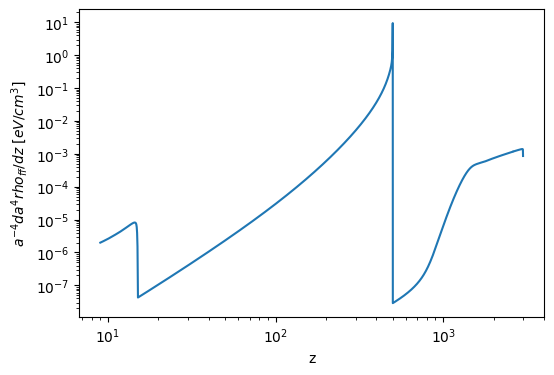

In [6]:
rs_arr = soln_base['rs']
z_arr  = rs_arr - 1

drhoffdz_arr = soln_base['softphot_hist'].drhoffdz_arr # ev / pcm^3 dz
#dTffdz_arr = (np.array(dTffdz_arr) * u.eV / c.k_B).to(u.K).value

import numpy as np

arr = np.array(drhoffdz_arr)
print("Nans:", np.isnan(arr).sum())
print("Infs:", np.isinf(arr).sum())
print("Zeros:", np.sum(arr == 0))
print("Min:", arr.min(), "Max:", arr.max())

print("X_MIN_SOFTPHOT =", soln_base['softphot_hist'].spec.x.min())
print("n_min, n_max =", np.nanmin(soln_base['softphot_hist'].spec.n),
                             np.nanmax(soln_base['softphot_hist'].spec.n))
print("dr_min, dr_max =", np.nanmin(drhoffdz_arr), np.nanmax(drhoffdz_arr))

print("len(rs) =", len(soln_base['rs']))
print("len(dr) =", len(soln_base['softphot_hist'].drhoffdz_arr))
print("Δ =", len(soln_base['rs']) - len(soln_base['softphot_hist'].drhoffdz_arr))

print("rs head:", soln_base['rs'][:5])
print("dr head:", soln_base['softphot_hist'].drhoffdz_arr[:5])

print("rs tail:", soln_base['rs'][-5:])
print("dr tail:", soln_base['softphot_hist'].drhoffdz_arr[-5:])


fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(z_arr[1:], np.abs(drhoffdz_arr[1:]), color='C0')
#ax.plot(z_arr, dTffdz_arr, color='C0')
#ax.plot(z_arr, -dTffdz_arr, ls='--', color='C0')
ax.set(xlabel='z', ylabel=r'$a^{-4} d a^{4} rho_{ff} / dz$ [$eV / cm^3$]')
_ = ax.set(xscale='log', yscale='log') #yscale changed to linear
# ax.axvline(1500, color='k', lw=1)
#ax.set(ylim=(1e-2, 1e5))

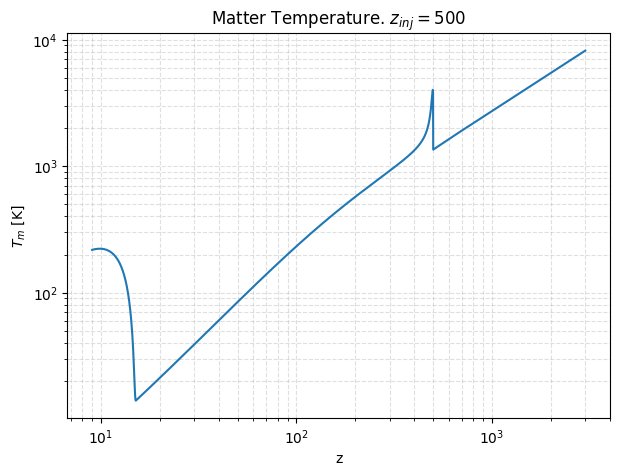

In [10]:
# Extract arrays
rs_arr = soln_base['rs']        # = 1+z
z_arr  = rs_arr - 1
Tm_arr = soln_base['Tm']
Tm_K = Tm_arr * 11604

plt.figure(figsize=(7,5))
plt.plot(z_arr, Tm_K, color='C0')
#plt.plot(z_arr, Tm_arr, color='C0')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("z")
plt.ylabel(r"$T_m$ [K]")
#plt.ylabel(r"$T_m$ [eV]")
plt.title(r"Matter Temperature. $z_{inj} = 500$")
plt.grid(True, which='both', ls='--', alpha=0.4)
plt.show()


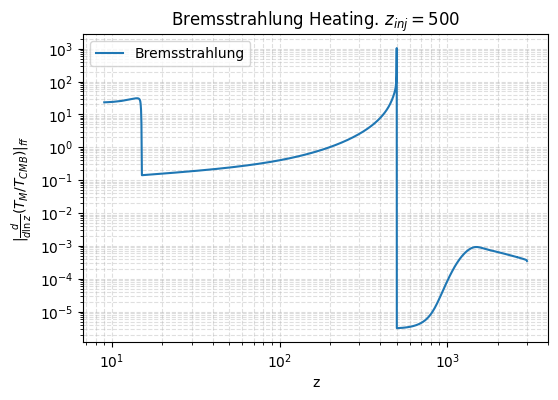

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u

rs = soln_base['rs']
z = rs - 1
Tm = soln_base['Tm']
drhoffdz = soln_base['softphot_hist'].drhoffdz_arr
xHII = soln_base['x'][ :, 0 ]
xHeII = soln_base['x'][ :, 1 ]
xHeIII = soln_base['x'][ :, 2 ] if soln_base['x'].shape[1] > 2 else 0

xe = xHII + xHeII + 2*xHeIII
nH = phys.nH * (1+z)**3 / u.cm**3
f_He = phys.nHe / phys.nH

chi = 1.5 * (nH.value) * (1 + xe + f_He)

Tcmb = phys.TCMB(1+z) * u.eV
Tcmb_eV = Tcmb.value

S_ff = -(1+z) * drhoffdz / (chi * Tcmb_eV)

plt.figure(figsize=(6,4))
plt.loglog(z[2:], np.abs(S_ff)[2:], label='Bremsstrahlung')
plt.xlabel("z")
plt.ylabel(r"$|\frac{d}{d\ln z}(T_M/T_{CMB})|_{ff}$")
plt.title(r"Bremsstrahlung Heating. $z_{inj} = 500$")
plt.grid(True, which='both', ls='--', alpha=0.4)
plt.legend()
plt.show()


In [9]:
spec = soln_base['softphot_hist'].spec  # at z_inj, right after injection

x = spec.x                      # dimensionless x
Delta_n = spec.n                # distortion

n_pl = 1 / (np.exp(x) - 1)

num   = np.trapezoid(x**3 * Delta_n,x)
den   = np.trapezoid(x**3 * n_pl,x)
rho_frac_measured = num / den
print("Measured Δρ/ρ =", rho_frac_measured)

Measured Δρ/ρ = 7.998057511259065e-07
